# Customer Retention and RFM

Recreates retention, time-to-second-purchase, cohort retention, RFM, and slide-number checks from Gold/Silver marts.


In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

_BOOT_ROOT = Path.cwd()
_MPL_DIR = (_BOOT_ROOT / "outputs" / ".matplotlib") if _BOOT_ROOT.name == "notebooks" else (_BOOT_ROOT / "notebooks" / "outputs" / ".matplotlib")
_MPL_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(_MPL_DIR.parent / ".cache"))

import numpy as np
import pandas as pd
import matplotlib
if os.environ.get("NOTEBOOK_VALIDATION") == "1":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Markdown
except Exception:
    def display(x): print(x)
    def Markdown(x): return x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().resolve()

SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
LEGACY_OUT = PROJECT_ROOT / "EDA" / "outputs"
NB_OUT = PROJECT_ROOT / "notebooks" / "outputs"
CHART_OUT = NB_OUT / "charts"
NB_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATE = pd.Timestamp("2026-04-30", tz="UTC")
MARGIN = 0.40

TEAL = "#2DC4A2"
NAVY = "#1A2E44"
SLATE = "#4A6274"
ORANGE = "#F07D3E"
RED = "#E84545"
GOLD_C = "#F7B731"
LILAC = "#9B72CF"
LIGHT_BG = "#F8F9FA"
CAT_COLORS = [TEAL, NAVY, ORANGE, GOLD_C, SLATE, RED, LILAC]
plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": LIGHT_BG,
    "axes.edgecolor": "#E2E8ED",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E2E8ED",
    "axes.labelcolor": NAVY,
    "axes.titlecolor": NAVY,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "legend.frameon": False,
    "font.family": ["DejaVu Sans"],
})

def money(x):
    return f"S${x:,.0f}"

def pct(x):
    return f"{x:.1%}"

RECREATED_CHARTS = []

def save_chart(fig, name):
    RECREATED_CHARTS.append(name)
    if os.environ.get("NOTEBOOK_VALIDATION") == "1":
        fig.canvas.draw()
    else:
        display(fig)
    plt.close(fig)
    print(f"rendered inline: {name}")
    return name

def load_marts():
    orders = pd.read_parquet(SILVER / "orders.parquet").copy()
    customers = pd.read_parquet(GOLD / "customers.parquet").copy()
    lines = pd.read_parquet(GOLD / "order_lines_enriched.parquet").copy()
    recharge_orders = pd.read_parquet(GOLD / "recharge_orders_enriched.parquet").copy()
    silver = {
        "discounts": pd.read_parquet(SILVER / "discounts.parquet"),
        "products": pd.read_parquet(SILVER / "products.parquet"),
        "campaigns": pd.read_parquet(SILVER / "campaigns.parquet"),
        "recharge_checkout": pd.read_parquet(SILVER / "recharge_checkout_items.parquet"),
        "recharge_recurring": pd.read_parquet(SILVER / "recharge_recurring_items.parquet"),
        "recharge_churned": pd.read_parquet(SILVER / "recharge_churned.parquet"),
        "recharge_reactivated": pd.read_parquet(SILVER / "recharge_reactivated.parquet"),
        "recharge_orders": pd.read_parquet(SILVER / "recharge_orders.parquet"),
    }
    orders["order_date"] = pd.to_datetime(orders["order_date"], utc=True)
    customers["first_order_date"] = pd.to_datetime(customers["first_order_date"], utc=True)
    customers["last_order_date"] = pd.to_datetime(customers["last_order_date"], utc=True)
    customers["second_order_date"] = pd.to_datetime(customers["second_order_date"], utc=True, errors="coerce")
    lines["order_date"] = pd.to_datetime(lines["order_date"], utc=True)

    orders["primary_revenue_sgd"] = pd.to_numeric(orders["order_revenue_sgd"], errors="coerce").fillna(0)
    orders["legacy_total_incl_shipping_sgd"] = pd.to_numeric(orders["order_total_incl_shipping_sgd"], errors="coerce").fillna(0)
    orders["Price: Total"] = orders["legacy_total_incl_shipping_sgd"]
    orders["Price: Total Discount"] = pd.to_numeric(orders["order_discount_sgd"], errors="coerce").fillna(0)
    orders["Price: Total Shipping"] = pd.to_numeric(orders["shipping_revenue_sgd"], errors="coerce").fillna(0)
    orders["revenue_basis_delta_sgd"] = orders["legacy_total_incl_shipping_sgd"] - orders["primary_revenue_sgd"]

    customers["total_revenue"] = pd.to_numeric(customers["total_revenue_sgd"], errors="coerce").fillna(0)
    customers["total_discount"] = pd.to_numeric(customers["total_discount_sgd"], errors="coerce").fillna(0)
    customers["first_product_cat"] = customers["first_product_category"]
    customers["is_repeat"] = customers["is_repeat"].astype(bool)

    for col in ["Line: Quantity", "Line: Price", "Line: Discount", "Line: Total"]:
        if col in lines.columns:
            lines[col] = pd.to_numeric(lines[col], errors="coerce").fillna(0)
    return orders, customers, lines, recharge_orders, silver

orders, customers, lines, recharge_orders, silver = load_marts()
print(f"Loaded marts: {len(orders):,} orders, {len(customers):,} customers, {len(lines):,} enriched lines")
print("Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.")


Loaded marts: 27,350 orders, 13,780 customers, 50,963 enriched lines
Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.


## Repeat Rate by Slice


In [2]:
def repeat_rate_table(groupcol):
    return (
        customers.groupby(groupcol)
        .agg(customers=("customer_id", "count"), repeaters=("is_repeat", "sum"), avg_orders=("total_orders", "mean"), avg_revenue=("total_revenue", "mean"))
        .assign(repeat_rate=lambda d: d.repeaters / d.customers)
        .sort_values("customers", ascending=False)
    )

slice_map = {
    "first_product_cat": "First Product Category",
    "first_channel": "Acquisition Channel",
    "first_store": "Store",
    "ever_subscribed": "Ever Subscribed",
    "ever_discounted": "Ever Discounted",
}
repeat_tables = []
for col, label in slice_map.items():
    tbl = repeat_rate_table(col)
    display(Markdown(f"### {label}"))
    display(tbl)
    tmp = tbl.reset_index().rename(columns={col: "slice_value"})
    tmp.insert(0, "slice_dimension", label)
    repeat_tables.append(tmp)
repeat_by_slice = pd.concat(repeat_tables, ignore_index=True)
repeat_by_slice.to_csv(NB_OUT / "01_repeat_rate_by_slice.csv", index=False)


### First Product Category

,customers,repeaters,avg_orders,avg_revenue,repeat_rate
first_product_cat,,,,,
Unknown,6908,2808,2.337435,332.320492,0.406485
Other,2480,626,1.874194,137.753099,0.252419
Clear Protein,1550,349,1.471613,108.338876,0.225161
Lean Protein,1324,307,1.444109,100.598999,0.231873
Accessories,696,154,1.395115,67.857874,0.221264
Collagen Glow,439,137,1.908884,127.832739,0.312073
Soy Protein,361,75,1.454294,87.766113,0.207756
Supplements,22,3,1.272727,104.187590,0.136364


### Acquisition Channel

,customers,repeaters,avg_orders,avg_revenue,repeat_rate
first_channel,,,,,
Direct / Organic,6920,2320,1.984393,195.523899,0.335260
Subscription,4275,1747,2.270409,338.748876,0.408655
Marketplace,2126,306,1.537629,114.312003,0.143932
Paid Social,382,74,1.408377,69.660759,0.193717
Email,48,6,1.375000,48.086307,0.125000
Affiliate,26,5,1.346154,90.739615,0.192308
Paid Search,3,1,1.333333,85.800000,0.333333


### Store

,customers,repeaters,avg_orders,avg_revenue,repeat_rate
first_store,,,,,
SG,8637,2354,1.792752,214.370204,0.272548
MY,5142,2105,2.307468,238.025365,0.409374
HK,1,0,1.000000,297.442623,0.000000


### Ever Subscribed

,customers,repeaters,avg_orders,avg_revenue,repeat_rate
ever_subscribed,,,,,
False,12685,3644,1.736303,196.904424,0.287268
True,1095,815,4.863014,527.860012,0.744292


### Ever Discounted

,customers,repeaters,avg_orders,avg_revenue,repeat_rate
ever_discounted,,,,,
False,7554,2202,1.733122,199.989356,0.291501
True,6226,2257,2.290074,251.368412,0.362512


## Time to Second Purchase and Cohort Retention


In [3]:
repeaters = customers[customers.is_repeat].copy()
repeaters["days_to_second"] = pd.to_numeric(repeaters.days_to_second, errors="coerce")
repeaters = repeaters.dropna(subset=["days_to_second"])

bins = [0,7,14,21,30,45,60,90,120,180,365,99999]
labels = ["0-7d","8-14d","15-21d","22-30d","31-45d","46-60d","61-90d","91-120d","121-180d","181-365d","365d+"]
repeaters["bucket"] = pd.cut(repeaters.days_to_second, bins=bins, labels=labels, right=True)
time_to_second = (
    repeaters.bucket.value_counts().reindex(labels).reset_index()
    .rename(columns={"bucket": "bucket", "count": "n_customers"})
    .assign(pct_of_repeaters=lambda d: d.n_customers / len(repeaters), cum_pct=lambda d: d.pct_of_repeaters.cumsum())
)
display(time_to_second)
time_to_second.to_csv(NB_OUT / "01_time_to_second_purchase.csv", index=False)

cutoff = ANALYSIS_DATE - pd.Timedelta(days=60)
cohort = customers.copy()
cohort["cohort_month"] = cohort.first_order_date.dt.to_period("M").astype(str)
eligible = cohort[cohort.first_order_date <= cutoff].copy()
eligible["repeat_in_60d"] = eligible.is_repeat & (eligible.days_to_second.fillna(9999) <= 60)
cohort_retention = (
    eligible.groupby("cohort_month")
    .agg(cohort_size=("customer_id", "count"), repeat_in_60d=("repeat_in_60d", "sum"), repeat_any_time=("is_repeat", "sum"))
    .assign(retention_60d=lambda d: d.repeat_in_60d / d.cohort_size, retention_ever=lambda d: d.repeat_any_time / d.cohort_size)
    .reset_index()
)
display(cohort_retention.tail(24))
cohort_retention.to_csv(NB_OUT / "01_cohort_retention_60d.csv", index=False)


,bucket,n_customers,pct_of_repeaters,cum_pct
0,0-7d,336,0.075353,0.075353
1,8-14d,222,0.049787,0.125140
2,15-21d,213,0.047769,0.172909
3,22-30d,355,0.079614,0.252523
4,31-45d,372,0.083427,0.335950
5,46-60d,320,0.071765,0.407715
6,61-90d,461,0.103386,0.511101
7,91-120d,257,0.057636,0.568737
8,121-180d,346,0.077596,0.646333
9,181-365d,450,0.100919,0.747253


,cohort_month,cohort_size,repeat_in_60d,repeat_any_time,retention_60d,retention_ever
51,2024-03,111,24,53,0.216216,0.477477
52,2024-04,148,39,54,0.263514,0.364865
53,2024-05,182,39,78,0.214286,0.428571
54,2024-06,154,34,52,0.220779,0.337662
55,2024-07,385,48,87,0.124675,0.225974
56,2024-08,315,30,71,0.095238,0.225397
57,2024-09,230,41,67,0.178261,0.291304
58,2024-10,141,27,46,0.191489,0.326241
59,2024-11,145,25,41,0.172414,0.282759
60,2024-12,93,15,33,0.161290,0.354839


## RFM Segmentation


In [4]:
rfm = customers.copy()
for col in ["recency_days", "total_orders", "total_revenue"]:
    rfm[col] = pd.to_numeric(rfm[col], errors="coerce").fillna(0)

def score_col(series, ascending=True, n=4):
    ranked = series.rank(method="first", ascending=ascending)
    bins = np.linspace(ranked.min() - 0.001, ranked.max() + 0.001, n + 1)
    return pd.cut(ranked, bins=bins, labels=list(range(1, n + 1))).astype(int)

def rfm_segment(r, f, m):
    if r == 4 and f >= 3 and m >= 3: return "Champions"
    if r >= 3 and f >= 2: return "Loyal"
    if r == 4 and f == 1: return "New Customers"
    if r == 3 and f == 1: return "Promising"
    if r <= 2 and f >= 3: return "At Risk"
    if r == 1 and f >= 2: return "Cant Lose"
    if r <= 2 and f <= 2: return "Hibernating"
    return "Others"

rfm["R"] = score_col(rfm.recency_days, ascending=False)
rfm["F"] = score_col(rfm.total_orders, ascending=True)
rfm["M"] = score_col(rfm.total_revenue, ascending=True)
rfm["RFM_score"] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)
rfm["segment"] = rfm.apply(lambda x: rfm_segment(x.R, x.F, x.M), axis=1)
rfm_summary = rfm.groupby("segment").agg(customers=("customer_id", "count"), avg_orders=("total_orders", "mean"), avg_revenue=("total_revenue", "mean"), avg_recency=("recency_days", "mean")).assign(pct_customers=lambda d: d.customers / d.customers.sum()).sort_values("customers", ascending=False)
display(rfm_summary)
rfm[["customer_id","R","F","M","RFM_score","segment","total_orders","total_revenue","recency_days","first_product_cat","first_channel","ever_subscribed"]].to_csv(NB_OUT / "01_rfm_segments.csv", index=False)


,customers,avg_orders,avg_revenue,avg_recency,pct_customers
segment,,,,,
Loyal,4354,1.918925,155.276988,366.003675,0.315965
Hibernating,3321,1.000000,109.843830,1517.246914,0.241001
At Risk,2351,3.368779,508.060890,1520.918758,0.170610
Champions,1833,3.182215,393.501895,142.159302,0.133019
Cant Lose,1218,1.000000,64.799159,1872.868637,0.088389
Promising,688,1.000000,57.013583,608.347384,0.049927
New Customers,15,1.000000,65.407333,157.266667,0.001089


## Slide Checks and Retention Charts


,metric,value
0,overall repeat rate,0.323585
1,repeaters within 90d as pct of repeaters,0.600527
2,median days to second purchase,49.000000


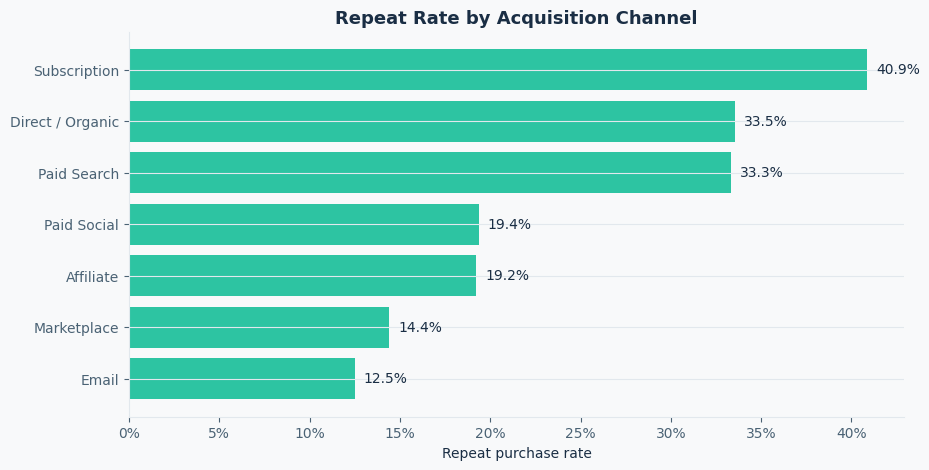

rendered inline: 02a_retention_by_channel


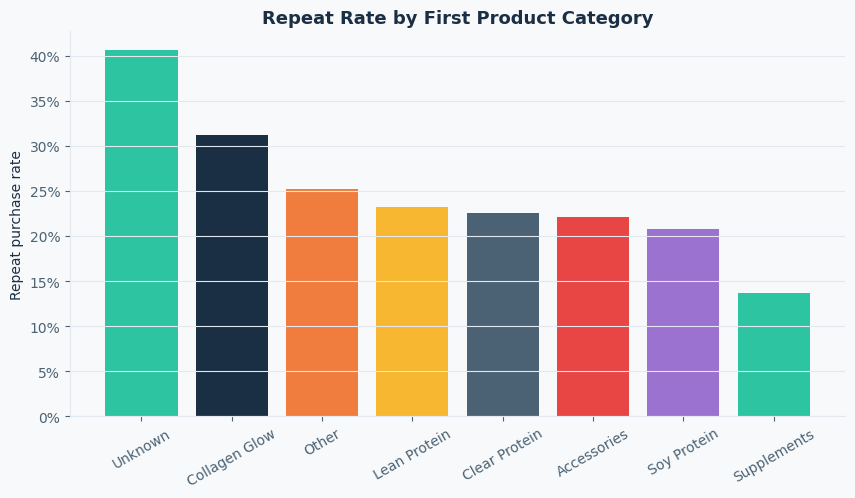

rendered inline: 02b_retention_by_product


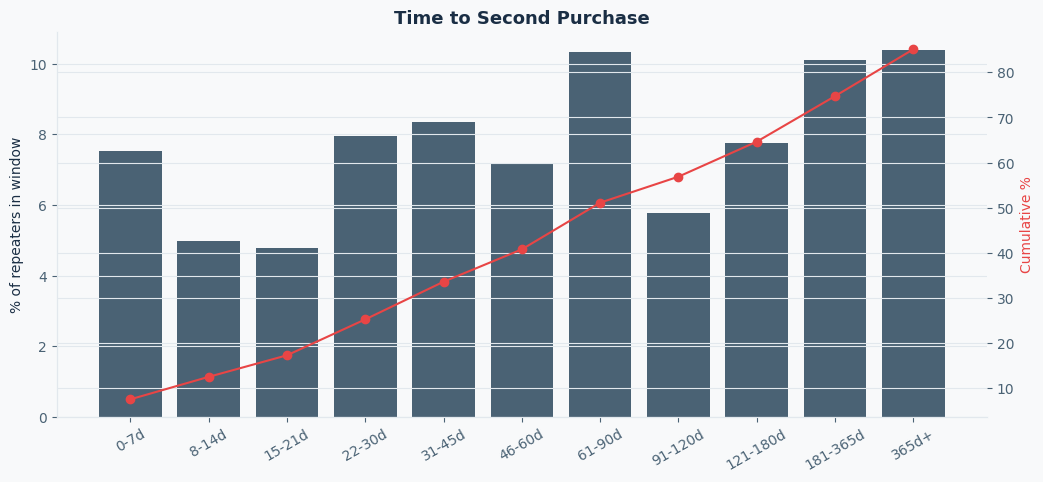

rendered inline: 02c_time_to_second_purchase


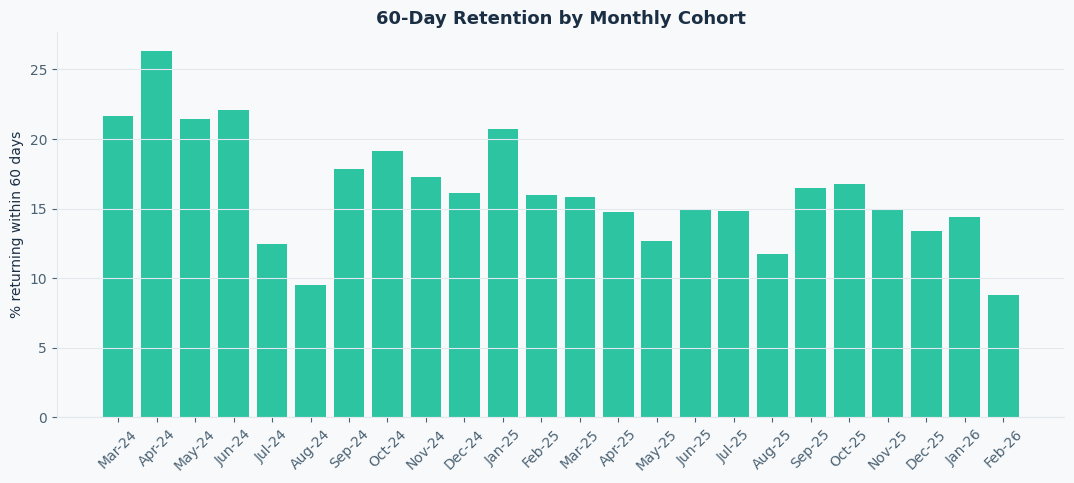

rendered inline: 02d_cohort_60d_retention


'02d_cohort_60d_retention'

In [5]:
within_90 = time_to_second[time_to_second.bucket.isin(["0-7d","8-14d","15-21d","22-30d","31-45d","46-60d","61-90d"])].n_customers.sum()
checks = pd.DataFrame([
    {"metric": "overall repeat rate", "value": customers.is_repeat.mean()},
    {"metric": "repeaters within 90d as pct of repeaters", "value": within_90 / time_to_second.n_customers.sum()},
    {"metric": "median days to second purchase", "value": repeaters.days_to_second.median()},
])
display(checks)
checks.to_csv(NB_OUT / "01_slide_checks.csv", index=False)

channel_quality = repeat_rate_table("first_channel").reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = channel_quality.sort_values("repeat_rate")
ax.barh(plot_df.first_channel, plot_df.repeat_rate * 100, color=TEAL)
ax.set_title("Repeat Rate by Acquisition Channel")
ax.set_xlabel("Repeat purchase rate")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
for i, v in enumerate(plot_df.repeat_rate * 100):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", color=NAVY)
save_chart(fig, "02a_retention_by_channel")

product_repeat = repeat_rate_table("first_product_cat").reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = product_repeat.sort_values("repeat_rate", ascending=False).head(8)
ax.bar(plot_df.first_product_cat, plot_df.repeat_rate * 100, color=CAT_COLORS[:len(plot_df)])
ax.set_title("Repeat Rate by First Product Category")
ax.set_ylabel("Repeat purchase rate")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(axis="x", rotation=30)
save_chart(fig, "02b_retention_by_product")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(time_to_second.bucket, time_to_second.pct_of_repeaters * 100, color=SLATE)
ax1.set_title("Time to Second Purchase")
ax1.set_ylabel("% of repeaters in window")
ax1.tick_params(axis="x", rotation=30)
ax2 = ax1.twinx()
ax2.plot(time_to_second.bucket, time_to_second.cum_pct * 100, color=RED, marker="o")
ax2.set_ylabel("Cumulative %", color=RED)
save_chart(fig, "02c_time_to_second_purchase")

fig, ax = plt.subplots(figsize=(13, 5))
last24 = cohort_retention.tail(24)
ax.bar(pd.to_datetime(last24.cohort_month).dt.strftime("%b-%y"), last24.retention_60d * 100, color=TEAL)
ax.set_title("60-Day Retention by Monthly Cohort")
ax.set_ylabel("% returning within 60 days")
ax.tick_params(axis="x", rotation=45)
save_chart(fig, "02d_cohort_60d_retention")
